In [275]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
#from imblearn.over_sampling import SMOTE

In [221]:
df = pd.read_csv("C:/Users/JunhuiHuTEST/PycharmProjects/Northeastern/aly6040/week1/diabetic_data.csv")
df.shape

(101766, 50)

In [222]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [223]:
df.head(10)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
5,35754,82637451,Caucasian,Male,[50-60),?,2,1,2,3,...,No,Steady,No,No,No,No,No,No,Yes,>30
6,55842,84259809,Caucasian,Male,[60-70),?,3,1,2,4,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
7,63768,114882984,Caucasian,Male,[70-80),?,1,1,7,5,...,No,No,No,No,No,No,No,No,Yes,>30
8,12522,48330783,Caucasian,Female,[80-90),?,2,1,4,13,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
9,15738,63555939,Caucasian,Female,[90-100),?,3,3,4,12,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [224]:
# delete duplicate by encounter id
df.drop_duplicates(subset='encounter_id', inplace=True)

In [225]:
df.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [226]:
# find outliers of numerical features
numeric_cols = ['time_in_hospital', 'num_lab_procedures', 'number_inpatient',
                'number_outpatient', 'number_emergency']

for col in numeric_cols:
    # calculate IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # find outliers
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col} outliers：{len(outliers)}")



time_in_hospital outliers：2252
num_lab_procedures outliers：143
number_inpatient outliers：7049
number_outpatient outliers：16739
number_emergency outliers：11383


In [227]:
#replace ? to NA
df.replace('?', pd.NA, inplace=True)
missing_percent = df.isna().mean() * 100
print(missing_percent)

encounter_id                 0.000000
patient_nbr                  0.000000
race                         2.233555
gender                       0.000000
age                          0.000000
weight                      96.858479
admission_type_id            0.000000
discharge_disposition_id     0.000000
admission_source_id          0.000000
time_in_hospital             0.000000
payer_code                  39.557416
medical_specialty           49.082208
num_lab_procedures           0.000000
num_procedures               0.000000
num_medications              0.000000
number_outpatient            0.000000
number_emergency             0.000000
number_inpatient             0.000000
diag_1                       0.020636
diag_2                       0.351787
diag_3                       1.398306
number_diagnoses             0.000000
max_glu_serum               94.746772
A1Cresult                   83.277322
metformin                    0.000000
repaglinide                  0.000000
nateglinide 

In [228]:
#drop high missing value column
df.drop(['weight', 'payer_code', 'medical_specialty'], axis=1, inplace=True)
df.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,41,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,59,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,11,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,44,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,51,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [229]:
#drop the medicine column with all the record are 'No'
drug_columns = df.columns[24:44]
to_drop = [col for col in drug_columns if df[col].nunique() <= 1]
df.drop(columns=to_drop, inplace=True)

In [230]:
# remove unknown and invalid gender
df = df[df['gender'] != 'Unknown/Invalid']

In [197]:
# drop id column, these two dont have analytics value
df.drop(columns=['encounter_id', 'patient_nbr'], inplace=True)

In [231]:
# remove '[' and ')' from age
df['age'] = df['age'].str.replace(r'[\[\]\(\)]', '', regex=True)

In [232]:
# binary classify readmitted to 0 or 1
df['readmitted'] = df['readmitted'].replace({'>30': 0, '<30': 1, 'NO': 0})
df.head()

C:\Users\JunhuiHuTEST\AppData\Local\Temp\ipykernel_22084\1169873442.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['readmitted'] = df['readmitted'].replace({'>30': 0, '<30': 1, 'NO': 0})


,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,0-10,6,25,1,1,41,...,No,No,No,No,No,No,No,No,No,0
1,149190,55629189,Caucasian,Female,10-20,1,1,7,3,59,...,No,Up,No,No,No,No,No,Ch,Yes,0
2,64410,86047875,AfricanAmerican,Female,20-30,1,1,7,2,11,...,No,No,No,No,No,No,No,No,Yes,0
3,500364,82442376,Caucasian,Male,30-40,1,1,7,2,44,...,No,Up,No,No,No,No,No,Ch,Yes,0
4,16680,42519267,Caucasian,Male,40-50,1,1,7,1,51,...,No,Steady,No,No,No,No,No,Ch,Yes,0


In [233]:
# One-Hot Encoding except diag_1-3
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols = [col for col in categorical_cols if col not in ['diag_1', 'diag_2', 'diag_3']]
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df.head()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,...,insulin_Up,glyburide-metformin_No,glyburide-metformin_Steady,glyburide-metformin_Up,glipizide-metformin_Steady,glimepiride-pioglitazone_Steady,metformin-rosiglitazone_Steady,metformin-pioglitazone_Steady,change_No,diabetesMed_Yes
0,2278392,8222157,6,25,1,1,41,0,1,0,...,False,True,False,False,False,False,False,False,True,False
1,149190,55629189,1,1,7,3,59,0,18,0,...,True,True,False,False,False,False,False,False,False,True
2,64410,86047875,1,1,7,2,11,5,13,2,...,False,True,False,False,False,False,False,False,True,True
3,500364,82442376,1,1,7,2,44,1,16,0,...,True,True,False,False,False,False,False,False,False,True
4,16680,42519267,1,1,7,1,51,0,8,0,...,False,True,False,False,False,False,False,False,False,True


In [250]:
# Diagnosis Category base on IDC-9
def map_diagnosis_category(code):
    try:
        code = str(code)
        if code.startswith('E') or code.startswith('V'):
            return 'External/Supplemental'
        code = float(code)
        if 390 <= code <= 459 or code == 785:
            return 'Circulatory'
        elif 460 <= code <= 519 or code == 786:
            return 'Respiratory'
        elif 520 <= code <= 579 or code == 787:
            return 'Digestive'
        elif 250 <= code < 251:
            return 'Diabetes'
        elif 800 <= code <= 999:
            return 'Injury'
        elif 710 <= code <= 739:
            return 'Musculoskeletal'
        elif 580 <= code <= 629 or code == 788:
            return 'Genitourinary'
        elif 140 <= code <= 239:
            return 'Neoplasms'
        elif code in [780, 781, 784] or 790 <= code <= 799:
            return 'Symptoms/Ill-defined'
        elif 240 <= code <= 279 and not (250 <= code < 251):
            return 'Endocrine (non-diabetes)'
        elif 680 <= code <= 709 or code == 782:
            return 'Skin/Subcutaneous'
        elif 1 <= code <= 139:
            return 'Infectious'
        elif 290 <= code <= 319:
            return 'Mental'
        elif 280 <= code <= 289:
            return 'Blood'
        elif 320 <= code <= 359:
            return 'Nervous'
        elif 630 <= code <= 679:
            return 'Pregnancy/Childbirth'
        elif 360 <= code <= 389:
            return 'Sense Organs'
        elif 740 <= code <= 759:
            return 'Congenital Anomalies'
        else:
            return 'Other'
    except:
        return 'Other'


In [235]:
#create new column with diagnosis category
for diag in ['diag_1', 'diag_2', 'diag_3']:
    df[diag + '_new'] = df[diag].apply(map_diagnosis_category)

In [236]:
#drop old diag code column
df.drop(columns=['diag_1', 'diag_2', 'diag_3'], inplace=True)


In [237]:
# df.head()

In [238]:
# One-Hot Encoding diagnosis category
df = pd.get_dummies(df, columns=['diag_1_new', 'diag_2_new', 'diag_3_new'], drop_first=True)

In [240]:
df.head()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,...,diag_3_new_Mental,diag_3_new_Musculoskeletal,diag_3_new_Neoplasms,diag_3_new_Nervous,diag_3_new_Other,diag_3_new_Pregnancy/Childbirth,diag_3_new_Respiratory,diag_3_new_Sense Organs,diag_3_new_Skin/Subcutaneous,diag_3_new_Symptoms/Ill-defined
0,2278392,8222157,6,25,1,1,41,0,1,0,...,False,False,False,False,True,False,False,False,False,False
1,149190,55629189,1,1,7,3,59,0,18,0,...,False,False,False,False,False,False,False,False,False,False
2,64410,86047875,1,1,7,2,11,5,13,2,...,False,False,False,False,False,False,False,False,False,False
3,500364,82442376,1,1,7,2,44,1,16,0,...,False,False,False,False,False,False,False,False,False,False
4,16680,42519267,1,1,7,1,51,0,8,0,...,False,False,False,False,False,False,False,False,False,False


EDA

<Axes: xlabel='readmitted', ylabel='count'>

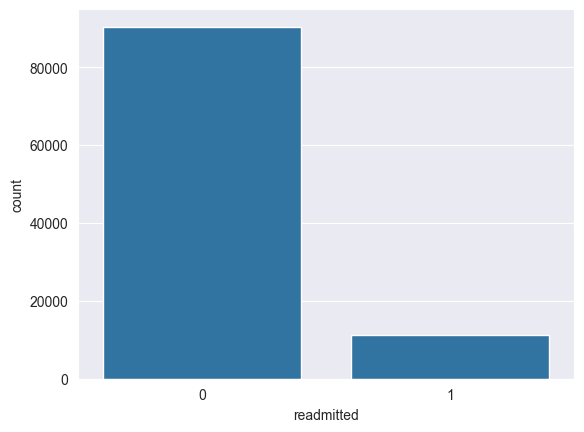

In [241]:
# Readmission Rate & Category Distribution
sns.countplot(x='readmitted', data=df)

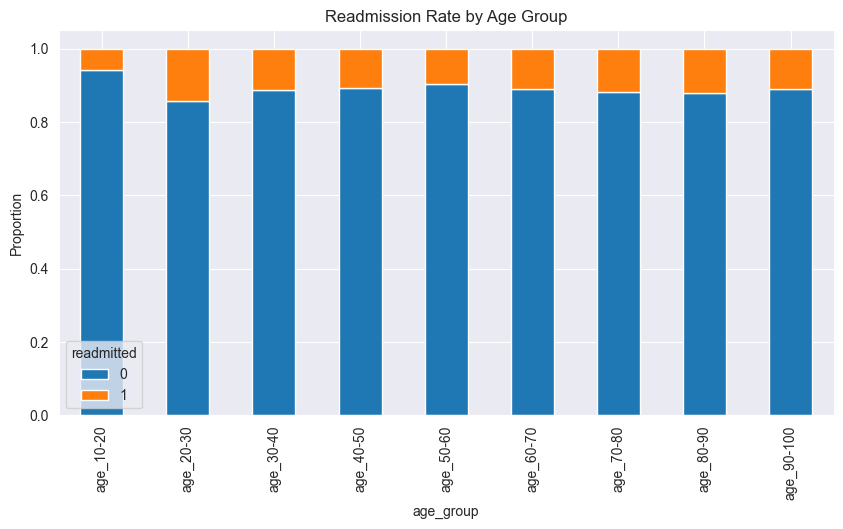

In [245]:
# age vs. readmitted
age_cols = [col for col in df.columns if col.startswith('age_')]
age_df = df[age_cols + ['readmitted']].melt(id_vars='readmitted', var_name='age_group', value_name='presence')
age_rate = age_df[age_df['presence'] == 1].groupby(['age_group', 'readmitted']).size().unstack().fillna(0)
(age_rate.div(age_rate.sum(axis=1), axis=0)).plot(kind='bar', stacked=True, figsize=(10,5), title='Readmission Rate by Age Group')
plt.ylabel('Proportion')
plt.show()

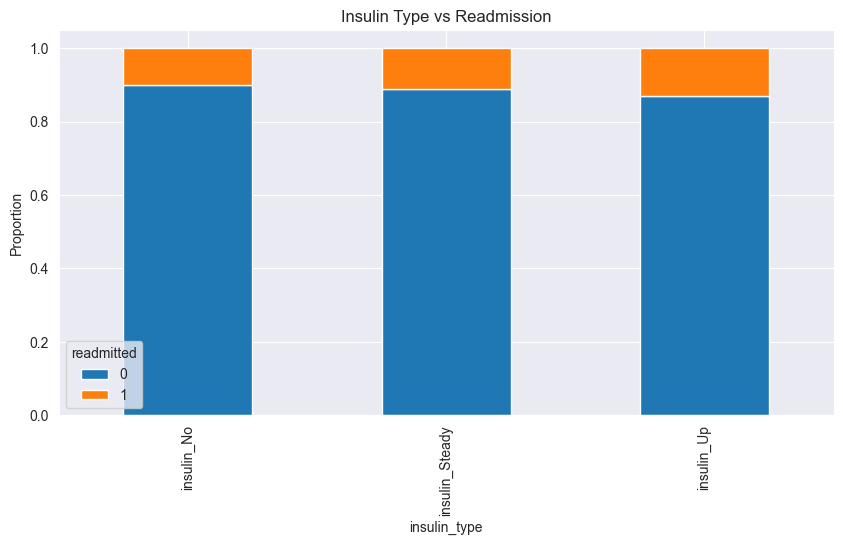

In [246]:
# time_in_hospital vs. readmitted
insulin_cols = [col for col in df.columns if col.startswith('insulin_')]
insulin_df = df[insulin_cols + ['readmitted']].melt(id_vars='readmitted', var_name='insulin_type', value_name='presence')
insulin_rate = insulin_df[insulin_df['presence'] == 1].groupby(['insulin_type', 'readmitted']).size().unstack().fillna(0)
(insulin_rate.div(insulin_rate.sum(axis=1), axis=0)).plot(kind='bar', stacked=True, figsize=(10,5), title='Insulin Type vs Readmission')
plt.ylabel('Proportion')
plt.show()

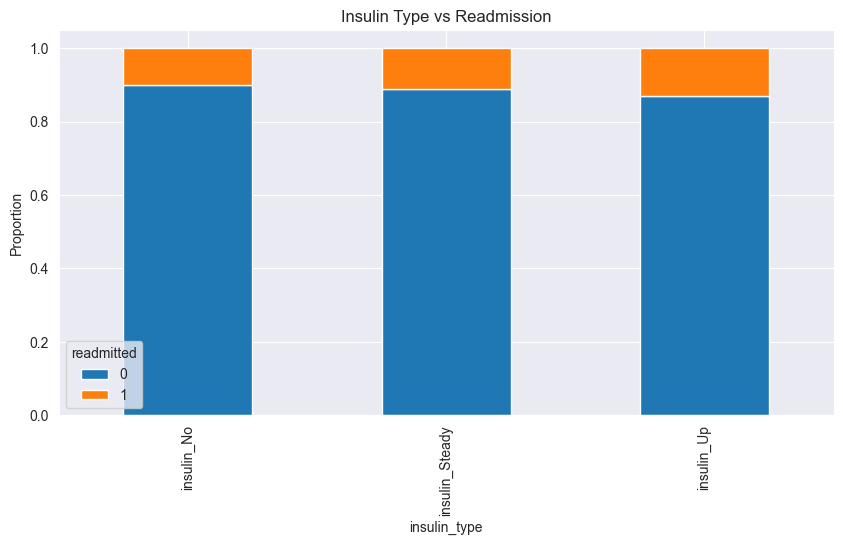

In [247]:
# insulin type vs. readmitted
insulin_cols = [col for col in df.columns if col.startswith('insulin_')]
insulin_df = df[insulin_cols + ['readmitted']].melt(id_vars='readmitted', var_name='insulin_type', value_name='presence')
insulin_rate = insulin_df[insulin_df['presence'] == 1].groupby(['insulin_type', 'readmitted']).size().unstack().fillna(0)
(insulin_rate.div(insulin_rate.sum(axis=1), axis=0)).plot(kind='bar', stacked=True, figsize=(10,5), title='Insulin Type vs Readmission')
plt.ylabel('Proportion')
plt.show()

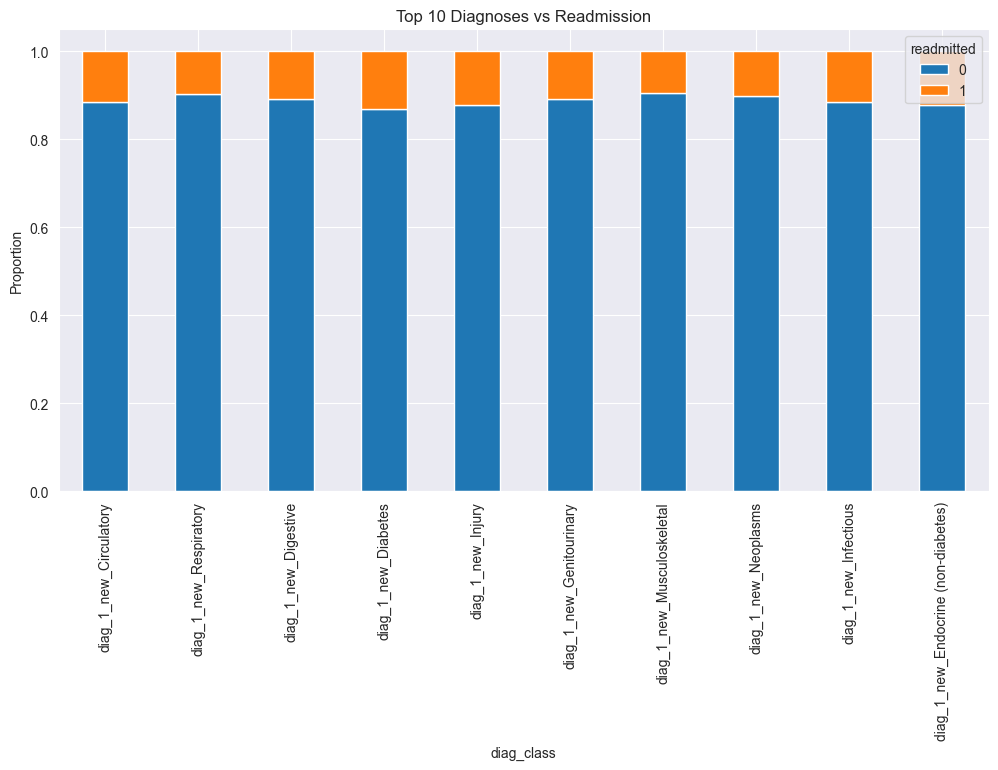

In [248]:
# dia 1 vs. readmitted
diag_cols = [col for col in df.columns if col.startswith('diag_1_new_')]
diag_df = df[diag_cols + ['readmitted']].melt(id_vars='readmitted', var_name='diag_class', value_name='presence')
diag_rate = diag_df[diag_df['presence'] == 1].groupby(['diag_class', 'readmitted']).size().unstack().fillna(0)
top_diag = diag_rate.sum(axis=1).sort_values(ascending=False).head(10).index
(diag_rate.loc[top_diag].div(diag_rate.loc[top_diag].sum(axis=1), axis=0)).plot(kind='bar', stacked=True, figsize=(12,6), title='Top 10 Diagnoses vs Readmission')
plt.ylabel('Proportion')
plt.show()

question: Can tree-based classification models effectively predict whether a diabetic patient will be readmitted to the hospital after discharge, based on their demographic attributes, medical history, and treatment patterns during hospitalization?

Model build

In [208]:
X = df.drop(columns=['readmitted'])
y = df['readmitted']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [209]:
models = {}
results = {}

In [210]:
# Decision Tree
start = time.time()
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
results['Decision Tree'] = {
    'accuracy': accuracy_score(y_test, dt_pred),
    'report': classification_report(y_test, dt_pred),
    'time': time.time() - start
}
models['Decision Tree'] = dt
print(results['Decision Tree'])

{'accuracy': 0.5669925809462979, 'report': '              precision    recall  f1-score   support\n\n           0       0.60      0.60      0.60     11016\n           1       0.53      0.53      0.53      9337\n\n    accuracy                           0.57     20353\n   macro avg       0.56      0.56      0.56     20353\nweighted avg       0.57      0.57      0.57     20353\n', 'time': 0.8350222110748291}


In [211]:
# Random Forest
start = time.time()
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
results['Random Forest'] = {
    'accuracy': accuracy_score(y_test, rf_pred),
    'report': classification_report(y_test, rf_pred),
    'time': time.time() - start
}
models['Random Forest'] = rf
print(results['Random Forest'])

{'accuracy': 0.6384316808332924, 'report': '              precision    recall  f1-score   support\n\n           0       0.64      0.74      0.69     11016\n           1       0.63      0.52      0.57      9337\n\n    accuracy                           0.64     20353\n   macro avg       0.64      0.63      0.63     20353\nweighted avg       0.64      0.64      0.63     20353\n', 'time': 9.093554496765137}


In [212]:
# XGBoost
start = time.time()
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
results['XGBoost'] = {
    'accuracy': accuracy_score(y_test, xgb_pred),
    'report': classification_report(y_test, xgb_pred),
    'time': time.time() - start
}
models['XGBoost'] = xgb
print(results['XGBoost'])

C:\Users\JunhuiHuTEST\PycharmProjects\Northeastern\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:30:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


{'accuracy': 0.6464403282071439, 'report': '              precision    recall  f1-score   support\n\n           0       0.66      0.72      0.69     11016\n           1       0.63      0.56      0.59      9337\n\n    accuracy                           0.65     20353\n   macro avg       0.64      0.64      0.64     20353\nweighted avg       0.64      0.65      0.64     20353\n', 'time': 0.2600891590118408}


In [251]:
df['readmitted_binary'] = df['readmitted'].replace({'>30': 0, '<30': 1, 'NO': 0})

# 特征与标签
X = df.drop(columns=['readmitted', 'readmitted_binary'], errors='ignore')
y = df['readmitted_binary']

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# SMOTE 过采样（只对训练集）
sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_train, y_train)

# 计算类别比例
scale_ratio = (y_train == 0).sum() / (y_train == 1).sum()

# 初始化 XGBoost 模型
model = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight=scale_ratio
)

# 模型训练
model.fit(X_resampled, y_resampled)

# 模型预测
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# 输出评估指标
print("✅ Classification Report:\n", classification_report(y_test, y_pred))
print("✅ ROC AUC Score: {:.4f}".format(roc_auc_score(y_test, y_proba)))

NameError: name 'SMOTE' is not defined

most important features

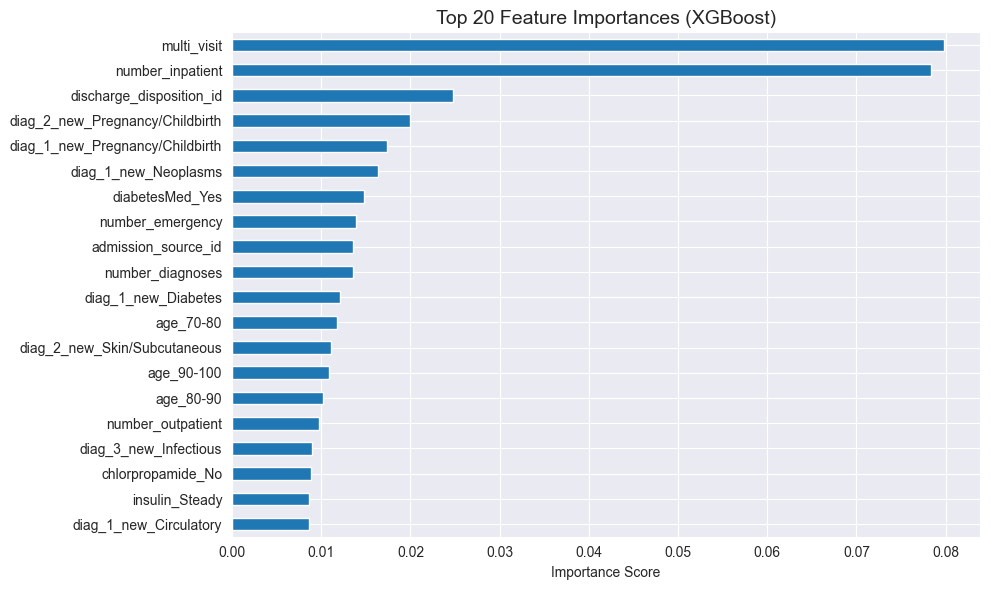

In [213]:
# most important features
best_model = xgb
xgb_importance = best_model.feature_importances_
feat_importances = pd.Series(xgb_importance, index=X.columns)

top_features = feat_importances.nlargest(20)

plt.figure(figsize=(10, 6))
top_features.sort_values().plot(kind='barh')
plt.title("Top 20 Feature Importances (XGBoost)", fontsize=14)
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

hyper-parameter tuning on the XGBoost model by using Grid Search

In [214]:
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
# new xgb model
xgb_upgrade = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
# gridsearch and 5 fold
grid = GridSearchCV(xgb_upgrade, param_grid, cv=5, scoring='f1', verbose=1, n_jobs=-1)
grid.fit(X_train, y_train)
# predict
y_pred = grid.predict(X_test)

#out put after parameter tuning
print("Best Parameters:", grid.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Fitting 5 folds for each of 48 candidates, totalling 240 fits


C:\Users\JunhuiHuTEST\PycharmProjects\Northeastern\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:31:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Accuracy: 0.6522379993121408
Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.73      0.69     11016
           1       0.64      0.56      0.60      9337

    accuracy                           0.65     20353
   macro avg       0.65      0.65      0.65     20353
weighted avg       0.65      0.65      0.65     20353



In [215]:

param_grid_rf = {
"n_estimators": [100, 200],
"max_depth": [5, 10],
"min_samples_split": [2, 5]
}
grid_rf = GridSearchCV(
RandomForestClassifier(random_state=42, n_jobs=-1),
param_grid=param_grid_rf,
cv=3,
n_jobs=-1,
verbose=1
)
grid_rf.fit(X_train, y_train)
print("Best RF Params:", grid_rf.best_params_)
print("Best RF CV Score:", grid_rf.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best RF Params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Best RF CV Score: 0.6333496812006537


In [216]:
param_grid_xgb = {
"n_estimators": [100, 200],
"learning_rate": [0.01, 0.05, 0.1],
"max_depth": [3, 5]
}
grid_xgb = GridSearchCV(
XGBClassifier(
use_label_encoder=False,
eval_metric="logloss",
random_state=42,
n_jobs=-1
),
param_grid=param_grid_xgb,
cv=3,
n_jobs=-1,
verbose=1
)
grid_xgb.fit(X_train, y_train)
print("Best XGB Params:", grid_xgb.best_params_)
print("Best XGB CV Score:", grid_xgb.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


C:\Users\JunhuiHuTEST\PycharmProjects\Northeastern\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [00:17:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best XGB Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Best XGB CV Score: 0.6428693974333414
